# When Chain-Ladder Factors Misbehave: Smoothing Reserves with Polars and Whittaker-Henderson

<div class="alert alert-block alert-info">
<b>TL;DR</b>

- We run a full Chain-Ladder reserving calculation for 233 insurers in a handful of <code>polars</code> expressions, cross-checked against R's <code>ChainLadder</code> package.
- We zoom in on one company whose incurred development pattern is non-monotonic (it has a saddle point) — the kind of pattern that trips up standard parametric curve fits.
- <b>Whittaker-Henderson</b> smoothing, a non-parametric method newly available as <code>scipy.signal.whittaker_henderson</code>, handles it gracefully and shifts that company's estimated Chain-Ladder reserves by about 3%.
</div>

Reserving actuaries usually reach for Excel or specialized software to run a Chain-Ladder. Here we show that a modern dataframe library is more than capable of the job — and that non-parametric smoothing can rescue development patterns that look too noisy or non-monotonic to fit with a parametric curve.

Using real claims data from https://www.casact.org/publications-research/research/research-resources/loss-reserving-data-pulled-naic-schedule-p, we show:
- How to prepare and calculate Chain-Ladder (CL) reserves with [polars](https://pola.rs/).
- How to apply [Whittaker-Henderson (WH) smoothing](https://en.wikipedia.org/wiki/Whittaker%E2%80%93Henderson_smoothing) on the CL development factors.

We select the *other liability* line of business. The data contains aggregated claim information for 233 companies ("GRNAME") in the US market over the 10 years from 1998 until 2007. More details are available in the link above.

To keep the analysis focused, we simplify a few things that would matter for a real closing:
- We neglect the fact that claims are not fully developed after 10 years. This is evident as incurred losses (paid + case reserves) do not equal paid losses at development lag 10. One remedy would be to add a tail factor.
- We neglect possible trends in the data, e.g. from inflation.
- Chain-Ladder factors are often computed using only a subset of recent accident years (e.g. the 5 most recent), rather than the full history. We use all available accident years instead — plain vanilla CL.

We use the latest accident year, 2007, as our *reporting year*, i.e. we simulate a year-end closing for the 2007 annual report.

## Claim Loss Data


In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# PP Auto Data Set, December 2025
# df = pl.read_csv("https://www.casact.org/sites/default/files/2026-03/ppauto_pos98-07%20%281%29.csv")

# Workers Compensation Data Set, December 2025
# df = pl.read_csv("https://www.casact.org/sites/default/files/2026-03/wkcomp_pos_98-07.csv")

# Commercial Auto Data Set, December 2025
# df = pl.read_csv("https://www.casact.org/sites/default/files/2026-03/comauto_pos_98-07.csv")

# Medical Malpractice Data Set, December 2025
# df = pl.read_csv("https://www.casact.org/sites/default/files/2026-03/medmal_pos_98-07.csv")

# Product Liability Data Set, December 2025
# df = pl.read_csv("https://www.casact.org/sites/default/files/2026-03/prodliab_pos_98-07.csv")

# Other Liability Data Set, December 2025
df = pl.read_csv("https://www.casact.org/sites/default/files/2026-03/othliab_pos_98-07.csv")

In [2]:
print(f"The data contains {df['GRNAME'].n_unique()} companies (GRNAME).")

REPORTING_YEAR = df["AccidentYear"].max()
print(f"The reporting year (max of accident year) is {REPORTING_YEAR}.")

print("Top 5 insurers with largest posted reserves in 2007:")
df_top5 = (
    df
    .filter(pl.col("DevelopmentYear") == pl.col("DevelopmentYear").max())
    .group_by("GRNAME")
    .agg(pl.sum("PostedReserves2007"))
    .top_k(5, by="PostedReserves2007")
)
df_top5

The data contains 233 companies (GRNAME).
The reporting year (max of accident year) is 2007.
Top 5 insurers with largest posted reserves in 2007:


GRNAME,PostedReserves2007
str,f64
"""State Farm Mut Grp""",1.1370e6
"""Employers Mut Co Of Des Moines""",442178.716
"""Dorinco Rein Co""",270885.25
"""Toa-Re Ins Co Of Amer""",208634.419
"""United Services Automobile Asn…",189353.934


The data is already in long format. Since this is historical data, every development lag is observed — so called "full triangles" (a better name would be rectangle). The data offers much more information than we need, so we select only:
- the upper left triangle (accident year + lag - 1 <= 2007 = reporting year)
- accident year
- development lag (note that `1` means the same as the accident year, not accident year + `1`)
- cumulated paid losses ("paid")
- incurred losses ("incurred")

Note that the following polars query would also work if the data were given on a single-claim basis, because we aggregate by accident year and development lag.

We calculate the individual development factors
- `f_paid`
- `f_inc`

and plot them for all companies.

In [3]:
df_triangle = (
    df
    .group_by("GRNAME", "AccidentYear", "DevelopmentLag")
    .agg(pl.sum("IncurredLosses").alias("Incurred"), pl.sum("CumPaidLoss").alias("Paid"))
    .sort("GRNAME", "AccidentYear", "DevelopmentLag")
    .with_columns(
        f_paid=pl.col("Paid") / pl.col("Paid").shift(1).over("AccidentYear"),
        f_inc=pl.col("Incurred") / pl.col("Incurred").shift(1).over("AccidentYear"),
    )
)
df_triangle  # the "full triangle"

GRNAME,AccidentYear,DevelopmentLag,Incurred,Paid,f_paid,f_inc
str,i64,i64,i64,i64,f64,f64
"""Adriatic Ins Co""",1998,1,50,0,null,null
"""Adriatic Ins Co""",1998,2,113,0,NaN,2.26
"""Adriatic Ins Co""",1998,3,164,101,inf,1.451327
"""Adriatic Ins Co""",1998,4,156,101,1.0,0.95122
"""Adriatic Ins Co""",1998,5,156,101,1.0,1.0
…,…,…,…,…,…,…
"""Yasuda Fire & Marine Ins Co Of…",2007,6,4875,3769,0.991581,0.689436
"""Yasuda Fire & Marine Ins Co Of…",2007,7,4437,3769,1.0,0.910154
"""Yasuda Fire & Marine Ins Co Of…",2007,8,5374,3769,1.0,1.211179


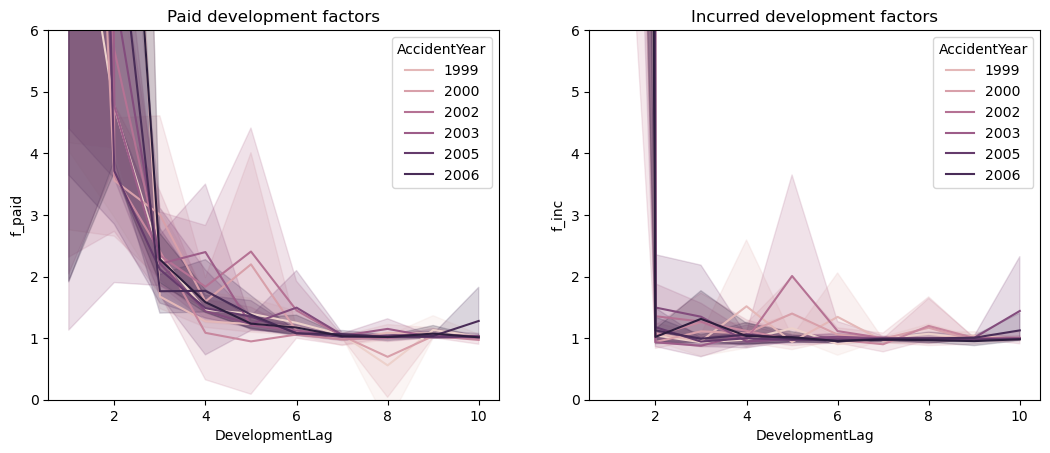

In [4]:
fig, axes = plt.subplots(ncols=2, figsize=[6.4 * 2, 4.8])
titles = {"f_paid": "Paid development factors", "f_inc": "Incurred development factors"}
for i, y in enumerate(["f_paid", "f_inc"]):
    sns.lineplot(
        data=df_triangle,
        x="DevelopmentLag",
        y=y,
        hue="AccidentYear",
        ax=axes[i],
    )
    axes[i].set(ylim=[0, 6], title=titles[y])

## Plain Chain-Ladder
Next, we calculate the Chain-Ladder development factors, again for both paid and incurred, this time separately for each company. Note that we take care to only account for the *upper left* triangle, which is what's usually available in practice.

In [5]:
def df_2_cl_factors(df, group_by=None):
    g = [] if group_by is None else group_by

    cl_factors = (
        df
        .group_by(g + ["AccidentYear", "DevelopmentLag"])
        .agg(pl.sum("Paid"), pl.sum("Incurred"))
        # Filter upper left triangle
        .filter(REPORTING_YEAR >= pl.col("AccidentYear") + pl.col("DevelopmentLag") - 1)
        .sort(g + ["AccidentYear", "DevelopmentLag"])
        .with_columns(
            PreviousPaid=pl.col("Paid").shift(1).over(g + ["AccidentYear"]),
            PreviousIncurred=pl.col("Incurred").shift(1).over(g + ["AccidentYear"]),
        )
        # Calculate volume-weighted factors per lag
        .group_by(g + ["DevelopmentLag"])
        .agg(
            number_of_years=pl.len(),
            Paid=pl.col("Paid").sum(),
            PreviousPaid=pl.col("PreviousPaid").sum(),
            Incurred=pl.col("Incurred").sum(),
            PreviousIncurred=pl.col("PreviousIncurred").sum(),
        )
        .with_columns(
            f_CL_paid=pl.when(pl.col("PreviousPaid") == 0).then(1).otherwise(pl.col("Paid") / pl.col("PreviousPaid")),
            f_CL_inc=pl.when(pl.col("PreviousIncurred") == 0).then(1).otherwise(pl.col("Incurred") / pl.col("PreviousIncurred")),
        )
        .sort(g + ["DevelopmentLag"])
    )
    return cl_factors

cl_factors = df_2_cl_factors(df_triangle, group_by=["GRNAME"])
cl_factors.filter(pl.col("GRNAME") == "Grinnell Mut Grp")


GRNAME,DevelopmentLag,number_of_years,Paid,PreviousPaid,Incurred,PreviousIncurred,f_CL_paid,f_CL_inc
str,i64,u32,i64,i64,i64,i64,f64,f64
"""Grinnell Mut Grp""",1,10,59563,0,191044,0,1.0,1.0
"""Grinnell Mut Grp""",2,9,89554,51851,172605,166116,1.727141,1.039063
"""Grinnell Mut Grp""",3,8,107323,77573,151543,151052,1.38351,1.003251
"""Grinnell Mut Grp""",4,7,106828,94039,129664,131101,1.135997,0.989039
"""Grinnell Mut Grp""",5,6,96179,88344,105967,106851,1.088687,0.991727
"""Grinnell Mut Grp""",6,5,82541,78467,86134,86800,1.05192,0.992327
"""Grinnell Mut Grp""",7,4,64703,63467,66151,66159,1.019475,0.999879
"""Grinnell Mut Grp""",8,3,48924,48535,49409,49457,1.008015,0.999029
"""Grinnell Mut Grp""",9,2,32840,32633,33029,32969,1.006343,1.00182


Let us verify the incurred Chain-Ladder factors of Grinnell Mut Grp with the result from [R ChainLadder](https://cran.r-project.org/package=ChainLadder):
```r
library(ChainLadder)
library(tidyverse)

df = read_csv("https://www.casact.org/sites/default/files/2026-03/othliab_pos_98-07.csv")
# Filter out lower right triangle
df_triangle = df |> filter(2007 >= AccidentYear + DevelopmentLag - 1)
# Create Triangle for Grinnell Mut Grp
tri_inc = as.triangle(
  df_triangle |> filter(GRNAME == "Grinnell Mut Grp"),
  origin = "AccidentYear", dev = "DevelopmentLag", value = "IncurredLosses"
)
# Chain-Ladder Factors
m_inc = MackChainLadder(tri_inc)
m_inc$f
```
results in
```
[1] 1.0390631 1.0032505 0.9890390 0.9917268 0.9923272 0.9998791 0.9990295 1.0018199 1.0004400 1.0000000
```
That is reassuring!

Note that in Python we are shifted by 1 development lag as compared to R ChainLadder. We stick to $C_j = f_j \cdot w_j$ with $C_j$ the cumulative paid or incurred at development lag $j$ and $w_j = C_{j-1}$ (index $i$ for accident year suppressed).

We plot the CL factors for the 5 largest insurers plus Grinnell Mut Grp and Virginia Mut Ins Co.

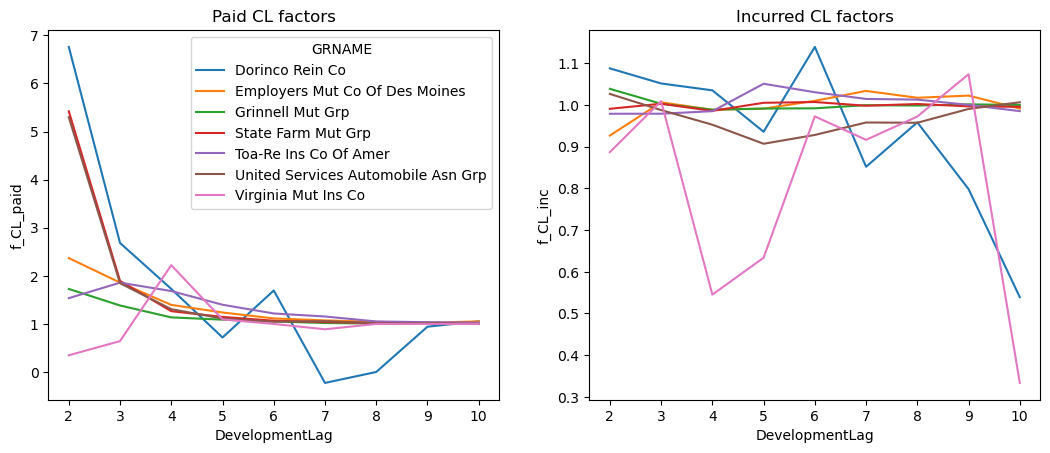

In [19]:
fig, axes = plt.subplots(ncols=2, figsize=[6.4 * 2, 4.8])
titles = {"f_CL_paid": "Paid CL factors", "f_CL_inc": "Incurred CL factors"}
for i, y in enumerate(["f_CL_paid", "f_CL_inc"]):
    sns.lineplot(
        data=cl_factors.filter(
            pl.col("GRNAME").is_in(["Grinnell Mut Grp", "Virginia Mut Ins Co"] + df_top5["GRNAME"].to_list()),
            pl.col("DevelopmentLag") >= 2,
        ),
        x="DevelopmentLag",
        y=y,
        hue="GRNAME",
        legend=i==0,
        ax=axes[i],
    ).set(title=titles[y])

We now focus on paid for Virginia Mut Ins Co and on incurred for Grinnell Mut Grp.

<div class="alert alert-block alert-info">
⚠️ <b>Note:</b>
Those two patterns are good showcases for reserving challenges faced in practice. They are not monotonic and don't seem stable. That's the reason I have chosen them.
</div>

[Text(0.5, 1.0, 'Paid CL for Virginia Mut Ins Co')]

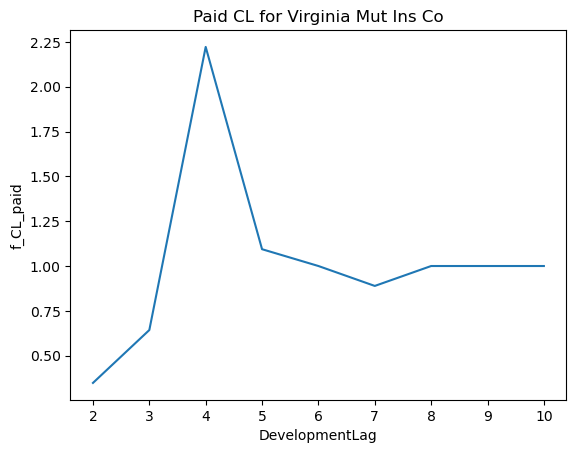

In [7]:
sns.lineplot(
    data=cl_factors.filter(
        pl.col("GRNAME") == "Virginia Mut Ins Co", pl.col("DevelopmentLag") >= 2
    ),
    x="DevelopmentLag",
    y="f_CL_paid",
).set(title="Paid CL for Virginia Mut Ins Co")

[Text(0.5, 1.0, 'Incurred CL for Grinnell Mut Grp')]

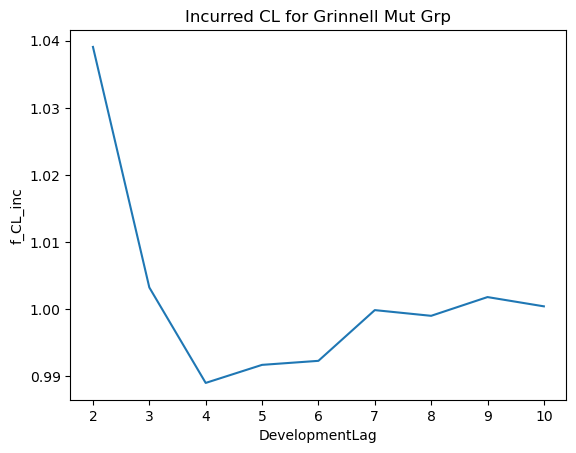

In [6]:
sns.lineplot(
    data=cl_factors.filter(
        pl.col("GRNAME") == "Grinnell Mut Grp", pl.col("DevelopmentLag") >= 2
    ),
    x="DevelopmentLag",
    y="f_CL_inc",
).set(title="Incurred CL for Grinnell Mut Grp")

My judgement is that both patterns need some work or at least further investigation. We focus on the incurred pattern of Grinnell Mut Grp and go on by predicting the ultimate loss and the resulting IBNR reserves (incurred but not reported; we follow the R ChainLadder terminology where IBNR is the difference between the ultimate loss and the value, paid or incurred; so IBNR may also include reserves for claims that are not yet settled).

In [16]:
def predict_ultimate(df_triangle, cl_factors):
    """Predict ultimate loss based on CL factors for paid and incurred.

    This filters the newest diagonal (REPORTING_YEAR) and calculates the cumulative
    CL factors F_CL = cumprod(f_CL) per accident year, as well as the ultimate loss.
    """
    return (
        df_triangle
        .drop("f_paid", "f_inc")
        # Filter diagonal
        .filter(REPORTING_YEAR == pl.col("AccidentYear") + pl.col("DevelopmentLag") - 1)
        # We want to predict the coming development, therefore increment DevelopmentLag
        .with_columns(pl.col("DevelopmentLag") + 1)
        .join(
            cl_factors
            .sort("DevelopmentLag", descending=True)
            .with_columns(
                F_CL_paid=pl.col("f_CL_paid").cum_prod().over("GRNAME"),
                F_CL_inc=pl.col("f_CL_inc").cum_prod().over("GRNAME"),
            )
            .select("GRNAME", "DevelopmentLag", "F_CL_paid", "F_CL_inc"),
            on=["GRNAME", "DevelopmentLag"], how="left",
        )
        .with_columns(pl.col("F_CL_paid", "F_CL_inc").fill_null(1))
        .with_columns(
            UltimatePaid=pl.col("F_CL_paid") * pl.col("Paid"),
            UltimateIncurred=pl.col("F_CL_inc") * pl.col("Incurred"),
        )
        .select(
            "GRNAME", "AccidentYear", "Paid", "Incurred",
            "F_CL_paid", "F_CL_inc", "UltimatePaid", "UltimateIncurred",
            (pl.col("UltimatePaid") - pl.col("Paid")).alias("IBNR_Paid"),
            (pl.col("UltimateIncurred") - pl.col("Incurred")).alias("IBNR_Incurred"),
        )
    )

(
    predict_ultimate(df_triangle=df_triangle, cl_factors=cl_factors)
    .filter(pl.col("GRNAME") == "Grinnell Mut Grp")
)

GRNAME,AccidentYear,Paid,Incurred,F_CL_paid,F_CL_inc,UltimatePaid,UltimateIncurred,IBNR_Paid,IBNR_Incurred
str,i64,i64,i64,f64,f64,f64,f64,f64,f64
"""Grinnell Mut Grp""",1998,15785,15915,1.0,1.0,15785.0,15915.0,0.0,0.0
"""Grinnell Mut Grp""",1999,17093,17121,1.002413,1.00044,17134.248111,17128.533757,41.248111,7.533757
"""Grinnell Mut Grp""",2000,16291,16440,1.008772,1.002261,16433.900376,16477.166276,142.900376,37.166276
"""Grinnell Mut Grp""",2001,16168,16694,1.016857,1.001288,16440.541975,16715.501675,272.541975,21.501675
"""Grinnell Mut Grp""",2002,19074,19975,1.03666,1.001167,19773.249907,19998.30906,699.249907,23.30906
"""Grinnell Mut Grp""",2003,17712,19167,1.090483,0.993485,19314.637336,19042.129814,1602.637336,-124.870186
"""Grinnell Mut Grp""",2004,18484,22813,1.187195,0.985266,21944.117114,22476.869675,3460.117114,-336.130325
"""Grinnell Mut Grp""",2005,13284,20442,1.34865,0.974466,17915.466242,19920.040707,4631.466242,-521.959293
"""Grinnell Mut Grp""",2006,11981,21553,1.86587,0.977634,22354.992725,21070.942748,10373.992725,-482.057252


In [17]:
(
    predict_ultimate(df_triangle=df_triangle, cl_factors=cl_factors)
    .filter(pl.col("GRNAME") == "Grinnell Mut Grp")
    .select(
        pl.col("GRNAME").first(),
        pl.col("Paid").sum(), pl.col("UltimatePaid").sum(), pl.col("IBNR_Paid").sum(),
        pl.col("Incurred").sum(), pl.col("UltimateIncurred").sum(), pl.col("IBNR_Incurred").sum(),
    )
)

GRNAME,Paid,UltimatePaid,IBNR_Paid,Incurred,UltimateIncurred,IBNR_Incurred
str,i64,f64,f64,i64,f64,f64
"""Grinnell Mut Grp""",153584,191949.011743,38365.011743,195048,194066.935495,-981.064505


Once more, let us compare with R ChainLadder, only the incurred:
```r
m_inc
```
```
MackChainLadder(Triangle = tri_inc)

     Latest Dev.To.Date Ultimate    IBNR Mack.S.E CV(IBNR)
1998 15,915       1.000   15,915    0.00        0      NaN
1999 17,121       1.000   17,129    7.53       65     8.63
2000 16,440       0.998   16,477   37.17      105     2.81
2001 16,694       0.999   16,716   21.50      180     8.39
2002 19,975       0.999   19,998   23.31      292    12.55
2003 19,167       1.007   19,042 -124.87      430    -3.44
2004 22,813       1.015   22,477 -336.13      847    -2.52
2005 20,442       1.026   19,920 -521.96    1,321    -2.53
2006 21,553       1.023   21,071 -482.06    1,821    -3.78
2007 24,928       0.984   25,322  394.44    3,281     8.32

              Totals
Latest:   195,048.00
Dev:            1.01
Ultimate: 194,066.94
IBNR:        -981.06
Mack.S.E    4,582.07
CV(IBNR):      -4.67
```
This validates our Chain-Ladder implementation in polars.

## Whittaker-Henderson Smoothing
For Grinnell Mut Grp, the incurred pattern at development lag 2 is larger than 1, then falls below 1 — meaning case reserves are significantly reduced, maybe due to subrogation recoveries (though the paid pattern gives no indication of that). After a few more years of development, the CL factors climb back above 1 with some zig-zag. This calls for smoothing.

Unfortunately, many commercial tools only offer parametric fits that are strictly monotonic, like the exponential function or an inverse power law (to be fair, parametric curve fits are more for tail factor estimation). Our pattern is clearly not monotonic — it has a saddle point. We therefore apply the non-parametric Whittaker-Henderson (WH) smoothing, which seems like the perfect fit for our case. The CL factors form a signal in discrete time with equal time steps (development lag in steps of one year). WH smoothing has two parameters (they are not fitted — it is a *non-parametric* method):
- penalty `order`: we use `order=2` differences, a common default and a good trade-off between smoothness and flexibility
- penalty strength `lamb`: this could be selected automatically via the REML criterion, but we choose it ourselves

Note:
- Whittaker-Henderson smoothing is available as [`scipy.signal.whittaker_henderson`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.whittaker_henderson.html) as of scipy 1.18 (released June 2026, `pip install "scipy>=1.18"`). I implemented it myself and, to my knowledge, it is the newest addition to scipy's signal smoothers/filters — even though the algorithm itself is the oldest, dating back to Georg Bohlmann in 1899 (it should really be called Bohlmann-Whittaker-Henderson) 😄
- We include `DevelopmentLag = 1` in the smoothing. As it has zero weight, WH extrapolates its value. For our predictions with `predict_ultimate`, it does not matter as the factor for `DevelopmentLag = 1` is ignored.

[Text(0.5, 1.0, 'Incurred CL for Grinnell Mut Grp')]

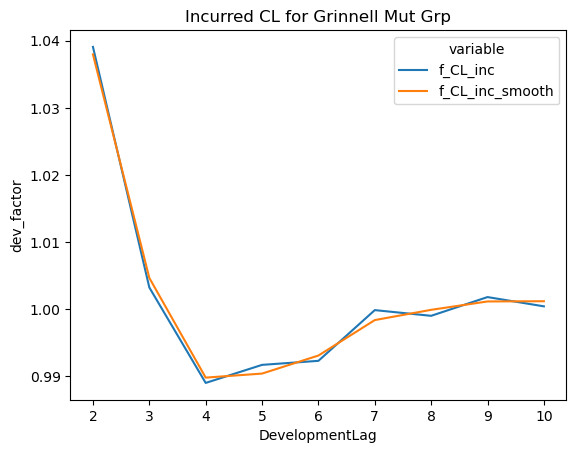

In [18]:
from scipy.signal import whittaker_henderson

cl_factors_smooth = cl_factors.filter(pl.col("GRNAME") == "Grinnell Mut Grp")
cl_factors_smooth = cl_factors_smooth.with_columns(
    f_CL_inc_smooth=whittaker_henderson(
        signal=cl_factors_smooth["f_CL_inc"], weights=cl_factors_smooth["PreviousIncurred"], lamb=1e4
    ).x
)

sns.lineplot(
    data=cl_factors_smooth
    .filter(pl.col("DevelopmentLag") >= 2)
    .unpivot(on=["f_CL_inc", "f_CL_inc_smooth"], index="DevelopmentLag", value_name="dev_factor"),
    x="DevelopmentLag",
    y="dev_factor",
    hue="variable",
).set(title="Incurred CL for Grinnell Mut Grp")

In [19]:
# Check
(
    cl_factors_smooth
    .filter(pl.col("DevelopmentLag") >= 2)
    .select(
        Incurred_predicted=(pl.col("f_CL_inc_smooth") * pl.col("PreviousIncurred")).sum(),
        Incurred=pl.col("Incurred").sum()
    )
)

Incurred_predicted,Incurred
f64,i64
810417.0,810417


The check we conducted was the reason to keep the column `PreviousIncurred` in the `cl_factors` dataframe. It confirms a property of the WH smoother: it preserves the weighted sum of the signal (in-sample). This means the smoothed CL factors reproduce the sum of observed values in the data used to fit. *Out-of-sample*, i.e. for the lower right triangle, the results diverge — as expected.

In [20]:
predict_ultimate(
    df_triangle=df_triangle.filter(pl.col("GRNAME") == "Grinnell Mut Grp"),
    cl_factors=cl_factors_smooth.with_columns(pl.col("f_CL_inc_smooth").alias("f_CL_inc")),
)


GRNAME,AccidentYear,Paid,Incurred,F_CL_paid,F_CL_inc,UltimatePaid,UltimateIncurred,IBNR_Paid,IBNR_Incurred
str,i64,i64,i64,f64,f64,f64,f64,f64,f64
"""Grinnell Mut Grp""",1998,15785,15915,1.0,1.0,15785.0,15915.0,0.0,0.0
"""Grinnell Mut Grp""",1999,17093,17121,1.002413,1.001203,17134.248111,17141.590818,41.248111,20.590818
"""Grinnell Mut Grp""",2000,16291,16440,1.008772,1.002372,16433.900376,16479.003299,142.900376,39.003299
"""Grinnell Mut Grp""",2001,16168,16694,1.016857,1.002293,16440.541975,16732.282687,272.541975,38.282687
"""Grinnell Mut Grp""",2002,19074,19975,1.03666,1.000685,19773.249907,19988.672891,699.249907,13.672891
"""Grinnell Mut Grp""",2003,17712,19167,1.090483,0.993796,19314.637336,19048.090944,1602.637336,-118.909056
"""Grinnell Mut Grp""",2004,18484,22813,1.187195,0.984285,21944.117114,22454.495458,3460.117114,-358.504542
"""Grinnell Mut Grp""",2005,13284,20442,1.34865,0.974274,17915.466242,19916.105073,4631.466242,-525.894927
"""Grinnell Mut Grp""",2006,11981,21553,1.86587,0.978824,22354.992725,21096.586899,10373.992725,-456.413101


| Accident Year | IBNR Incurred CL | IBNR Incurred WH Smoothed |
| ---: |  ---: |   ---: |
|  1998 |   0.0  |    0.0 |
|  1999 |   7.5  |   20.6 |
|  2000 |   37.2 |   39.0 |
|  2001 |   21.5 |   38.3 |
|  2002 |   23.3 |   13.7 |
|  2003 | -124.9 | -118.9 |
|  2004 | -336.1 | -358.5 |
|  2005 | -522.0 | -525.9 |
|  2006 | -482.1 | -456.4 |
|  2007 |  394.4 |  398.2 |
| TOTAL | -981.1 | -950.0 |

The difference in reserves of 31.1 is an increase of about 3%.

Now to the last question: which method is better for this triangle? Fortunately, we actually have the lower right triangle available: the values as they stood after all 10 years of development. Recall that even after 10 years of development the claims are not all settled. But it is the best we have at hand for comparison.

In [22]:
predict_ultimate(
    df_triangle=df_triangle.filter(pl.col("GRNAME") == "Grinnell Mut Grp"),
    cl_factors=cl_factors_smooth.with_columns(pl.col("f_CL_inc_smooth").alias("f_CL_inc")),
).select(pl.col("UltimatePaid").sum(), pl.col("UltimateIncurred").sum())

UltimatePaid,UltimateIncurred
f64,f64
191949.011743,194097.999921


In [35]:
df_triangle_grinnell = df_triangle.filter(pl.col("GRNAME") == "Grinnell Mut Grp")
df_ave = (
    df_triangle_grinnell
    .filter(pl.col("DevelopmentLag") == 10)
    .join(
            predict_ultimate(
                df_triangle=df_triangle_grinnell,
                cl_factors=cl_factors
            ).select("AccidentYear", pl.col("UltimateIncurred").alias("UltimateIncurred_CL")),
            on = "AccidentYear"
        )
    .join(
        predict_ultimate(
            df_triangle=df_triangle_grinnell,
            cl_factors=cl_factors_smooth.with_columns(pl.col("f_CL_inc_smooth").alias("f_CL_inc")),
        ).select("AccidentYear", pl.col("UltimateIncurred").alias("UltimateIncurred_CL_smooth")),
        on = "AccidentYear"
    )
    .select(
        "GRNAME", "AccidentYear", "Incurred", "UltimateIncurred_CL", "UltimateIncurred_CL_smooth",
        (pl.col("Incurred") - pl.col("UltimateIncurred_CL")).alias("Actual_vs_Expected_CL"),
        (pl.col("Incurred") - pl.col("UltimateIncurred_CL_smooth")).alias("Actual_vs_Expected_CL_smooth"), 
    )
)
df_ave

GRNAME,AccidentYear,Incurred,UltimateIncurred_CL,UltimateIncurred_CL_smooth,Actual_vs_Expected_CL,Actual_vs_Expected_CL_smooth
str,i64,i64,f64,f64,f64,f64
"""Grinnell Mut Grp""",1998,15915,15915.0,15915.0,0.0,0.0
"""Grinnell Mut Grp""",1999,17177,17128.533757,17141.590818,48.466243,35.409182
"""Grinnell Mut Grp""",2000,16331,16477.166276,16479.003299,-146.166276,-148.003299
"""Grinnell Mut Grp""",2001,16787,16715.501675,16732.282687,71.498325,54.717313
"""Grinnell Mut Grp""",2002,20083,19998.30906,19988.672891,84.69094,94.327109
"""Grinnell Mut Grp""",2003,19012,19042.129814,19048.090944,-30.129814,-36.090944
"""Grinnell Mut Grp""",2004,22271,22476.869675,22454.495458,-205.869675,-183.495458
"""Grinnell Mut Grp""",2005,19462,19920.040707,19916.105073,-458.040707,-454.105073
"""Grinnell Mut Grp""",2006,18969,21070.942748,21096.586899,-2101.942748,-2127.586899


In [37]:
df_ave.select(
    "Incurred", "UltimateIncurred_CL", "UltimateIncurred_CL_smooth",
    "Actual_vs_Expected_CL", "Actual_vs_Expected_CL_smooth",
).sum()

Incurred,UltimateIncurred_CL,UltimateIncurred_CL_smooth,Actual_vs_Expected_CL,Actual_vs_Expected_CL_smooth
i64,f64,f64,f64,f64
189901,194066.935495,194097.999921,-4165.935495,-4196.999921


We see that both CL and smoothed CL seem to overestimate. The smoothed CL ultimate is even a bit higher than the plain CL ultimate, so for this single company the un-smoothed CL turns out marginally closer to the actual outcome. To be fair, the difference (about 31 out of roughly -4,180) is small compared to the Mack standard error of 4,582 reported by R ChainLadder above, so neither method can be called clearly better here.

## Conclusion
We have seen how easy it is to implement a basic Chain-Ladder method in polars, and how a non-parametric smoother like Whittaker-Henderson comes in handy when development factors are too noisy — or simply not monotonic enough — for a parametric curve. Checking both methods against the actual, fully-developed incurred losses, both overestimated the ultimate, with plain CL marginally closer than the smoothed version — though the gap is well within the estimation uncertainty. Smoothing made the development pattern easier to reason about, but it did not automatically make the forecast more accurate, a good reminder to always validate against a holdout when one is available.

A few takeaways:

- polars' `group_by` + window (`.over(...)`) expressions make triangle wrangling and CL factor calculation compact and fast, even across hundreds of companies at once.
- Volume-weighted CL factors computed in polars match the R `ChainLadder` package exactly.
- Whittaker-Henderson smoothing is a flexible, non-parametric alternative to parametric curve fitting, and is now built into scipy as [`scipy.signal.whittaker_henderson`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.whittaker_henderson.html). A smoother pattern is not automatically a more accurate one, so it is worth checking against a holdout, as we did above.

Natural next steps would be to add a tail factor, estimate reserve uncertainty more formally (e.g. à la Mack's method), or let REML pick `lamb` automatically instead of choosing it by eye.

This notebook was AI reviewed.